In [ ]:
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
%matplotlib inline

In [ ]:
sheet_id = input("Enter Google Sheet ID: ")
sheet_name = input("Enter Sheet Name: ")
gid = input("Enter GID")
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)

In [3]:
df["Call Date"] = pd.to_datetime(df["Call Date"])

In [4]:
agent_name = "Aarti Verma"

agent_df = df[df["Master Agent Name"] == agent_name]

month = 6
year = 2026

agent_df = agent_df[
    (agent_df["Call Date"].dt.month == month) &
    (agent_df["Call Date"].dt.year == year)
]

In [5]:
print(df["Master Agent Name"].unique())

<ArrowStringArray>
[               nan,           'Roshni', 'Narayan Deekshit',
      'Aarti Verma',  'Suman Khatarkar',          'Radhika',
   'Aradhana Tyagi',            'Divya',      'Rahul Kumar']
Length: 9, dtype: str


In [6]:
daily_calls = (
    agent_df.groupby(agent_df["Call Date"].dt.date)["Call Id"]
    .count()
    .reset_index()
)

daily_calls.columns = ["Date", "Calls Done"]

daily_calls

,Date,Calls Done
0,2026-06-12,1
1,2026-06-19,54
2,2026-06-20,49
3,2026-06-22,66
4,2026-06-23,76
5,2026-06-24,78
6,2026-06-25,75
7,2026-06-26,57
8,2026-06-29,87
9,2026-06-30,107


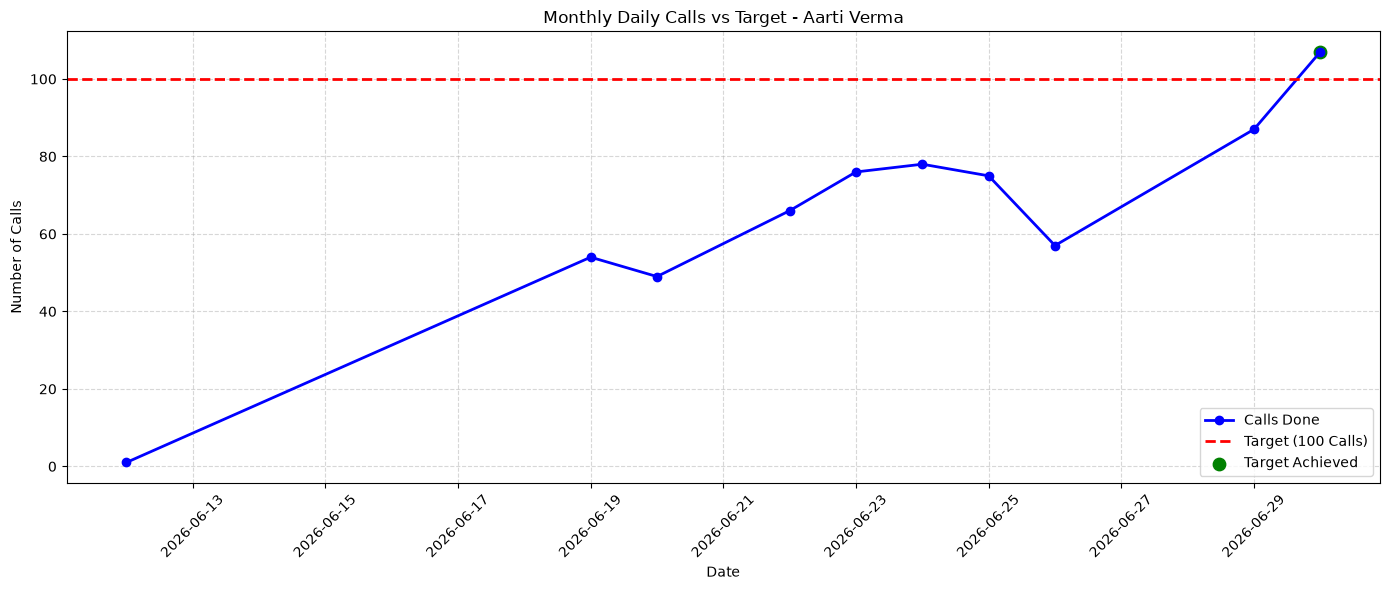

In [7]:
plt.figure(figsize=(14,6))


plt.plot(
    daily_calls["Date"],
    daily_calls["Calls Done"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Calls Done"
)


plt.axhline(
    y=100,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Target (100 Calls)"
)


above_target = daily_calls[daily_calls["Calls Done"] >= 100]

plt.scatter(
    above_target["Date"],
    above_target["Calls Done"],
    color="green",
    s=80,
    label="Target Achieved"
)

plt.title(f"Monthly Daily Calls vs Target - {agent_name}")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
%pip install --upgrade ipywidgets notebook
%pip show jupyterlab_widgets

Name: jupyterlab_widgets
Version: 3.0.16
Summary: Jupyter interactive widgets for JupyterLab
Home-page: https://github.com/jupyter-widgets/ipywidgets
Author: 
Author-email: Jupyter Development Team <jupyter@googlegroups.com>
License: Copyright (c) 2015 Project Jupyter Contributors
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

3. Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

THIS SOFT

In [ ]:
import pandas as pd # type: ignore
import plotly.graph_objects as go # type: ignore
import plotly.express as px # type: ignore
import ipywidgets as widgets # type: ignore
from IPython.display import display, clear_output # type: ignore

sheet_id = "1ldUkVn8ggpAZ3zXCB3_-Q05dxSkmlc0nyZR2c8l3ADs"
sheet_name = "Sheet1"
gid = "237812588"  
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/gviz/tq?tqx=out:csv&sheet={sheet_name}"
df = pd.read_csv(url)

df["Call Date"] = pd.to_datetime(df["Call Date"])


daily_calls = (
    df.groupby([df["Call Date"].dt.date, "Master Agent Name"])["Call Id"]
      .count()
      .reset_index(name="Calls Done")
)

daily_calls.rename(columns={"Call Date": "Date"}, inplace=True)


agents = sorted(daily_calls["Master Agent Name"].unique())

checkboxes = [
    widgets.Checkbox(
        value=False,
        description=agent,
        indent=False
    )
    for agent in agents
]



target_input = widgets.BoundedIntText(
    value=100,
    min=0,
    max=500,
    step=5,
    description="Target:"
)



button = widgets.Button(
    description="Update Chart",
    button_style="success",
    icon="refresh"
)



output = widgets.Output()



def plot_chart(button):

    with output:

        clear_output(wait=True)

        selected_agents = [
            cb.description
            for cb in checkboxes
            if cb.value
        ]

        if len(selected_agents) == 0:
            print("Please select at least one agent.")
            return

        target = target_input.value

        fig = go.Figure()

        colors = px.colors.qualitative.Dark24

        for i, agent in enumerate(selected_agents):

            temp = daily_calls[
                daily_calls["Master Agent Name"] == agent
            ].sort_values("Date")

            border_colors = [
                "green" if calls >= target else "black"
                for calls in temp["Calls Done"]
            ]

            fig.add_trace(

                go.Scatter(

                    x=temp["Date"],

                    y=temp["Calls Done"],

                    mode="lines+markers",

                    name=agent,

                    line=dict(
                        color=colors[i % len(colors)],
                        width=3
                    ),

                    marker=dict(
                        size=10,
                        color=colors[i % len(colors)],
                        line=dict(
                            color=border_colors,
                            width=3
                        )
                    ),

                    hovertemplate=
                    "<b>Agent:</b> %{fullData.name}<br>"
                    "<b>Date:</b> %{x}<br>"
                    "<b>Calls:</b> %{y}<extra></extra>"
                )
            )
        fig.add_hline(
            y=target,
            line_dash="dash",
            line_color="red",
            line_width=3,
            annotation_text=f"Target = {target}"
        )

        fig.update_layout(

            title="Daily Calls vs Target",

            xaxis_title="Date",

            yaxis_title="Calls Done",

            template="plotly_white",

            hovermode="closest",

            height=650,

            legend_title="Agents"
        )

        fig.show()

button.on_click(plot_chart)



display(widgets.HTML("<h3>Select Agents</h3>"))

display(widgets.VBox(checkboxes))

display(target_input)

display(button)

display(output)

HTML(value='<h3>Select Agents</h3>')

BoundedIntText(value=100, description='Target:', max=500, step=5)

Button(button_style='success', description='Update Chart', icon='refresh', style=ButtonStyle())

Output()